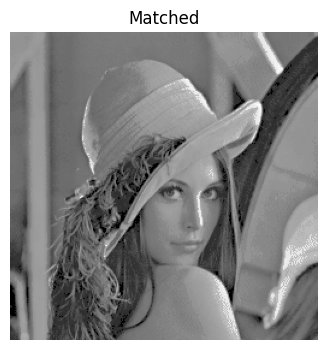

Dropdown(description='Mode:', index=2, options=('Source', 'Reference', 'Matched'), value='Matched')

Button(description='Tampilkan', style=ButtonStyle())

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================
# UPLOAD GAMBAR
# =========================
print("Upload gambar SOURCE")
src_upload = files.upload()

print("Upload gambar REFERENCE")
ref_upload = files.upload()

src = cv2.imread(list(src_upload.keys())[0], 0)
ref = cv2.imread(list(ref_upload.keys())[0], 0)

# =========================
# FUNGSI HISTOGRAM MATCHING
# =========================
def hist_match(source, template):
    oldshape = source.shape
    source = source.ravel()
    template = template.ravel()

    s_values, bin_idx, s_counts = np.unique(source, return_inverse=True, return_counts=True)
    t_values, t_counts = np.unique(template, return_counts=True)

    s_quantiles = np.cumsum(s_counts).astype(np.float64)
    s_quantiles /= s_quantiles[-1]

    t_quantiles = np.cumsum(t_counts).astype(np.float64)
    t_quantiles /= t_quantiles[-1]

    interp_t_values = np.interp(s_quantiles, t_quantiles, t_values)

    return interp_t_values[bin_idx].reshape(oldshape)

# =========================
# PROSES GUI
# =========================
def process_image(mode):
    clear_output(wait=True)

    if mode == "Source":
        result = src
    elif mode == "Reference":
        result = ref
    elif mode == "Matched":
        result = hist_match(src, ref)

    plt.figure(figsize=(5,4))
    plt.title(mode)
    plt.imshow(result, cmap='gray')
    plt.axis('off')
    plt.show()

    display(dropdown, button)

# =========================
# WIDGET
# =========================
dropdown = widgets.Dropdown(
    options=["Source", "Reference", "Matched"],
    description='Mode:',
)

button = widgets.Button(description="Tampilkan")

def on_click(b):
    process_image(dropdown.value)

button.on_click(on_click)

display(dropdown, button)